In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import cv2
import os
import tqdm
import numpy as np
from torch.utils.data import DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
import os
import cv2

train_folder_path_x = "low_resolution"
train_folder_path_y = "high_resolution"
data_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            data_tuple.append((image_x,image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [8]:
from sklearn.model_selection import train_test_split
train_tuple, test_tuple = train_test_split(data_tuple, test_size=0.1, random_state=42)

In [9]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

810
(128, 128, 3)
(512, 512, 3)


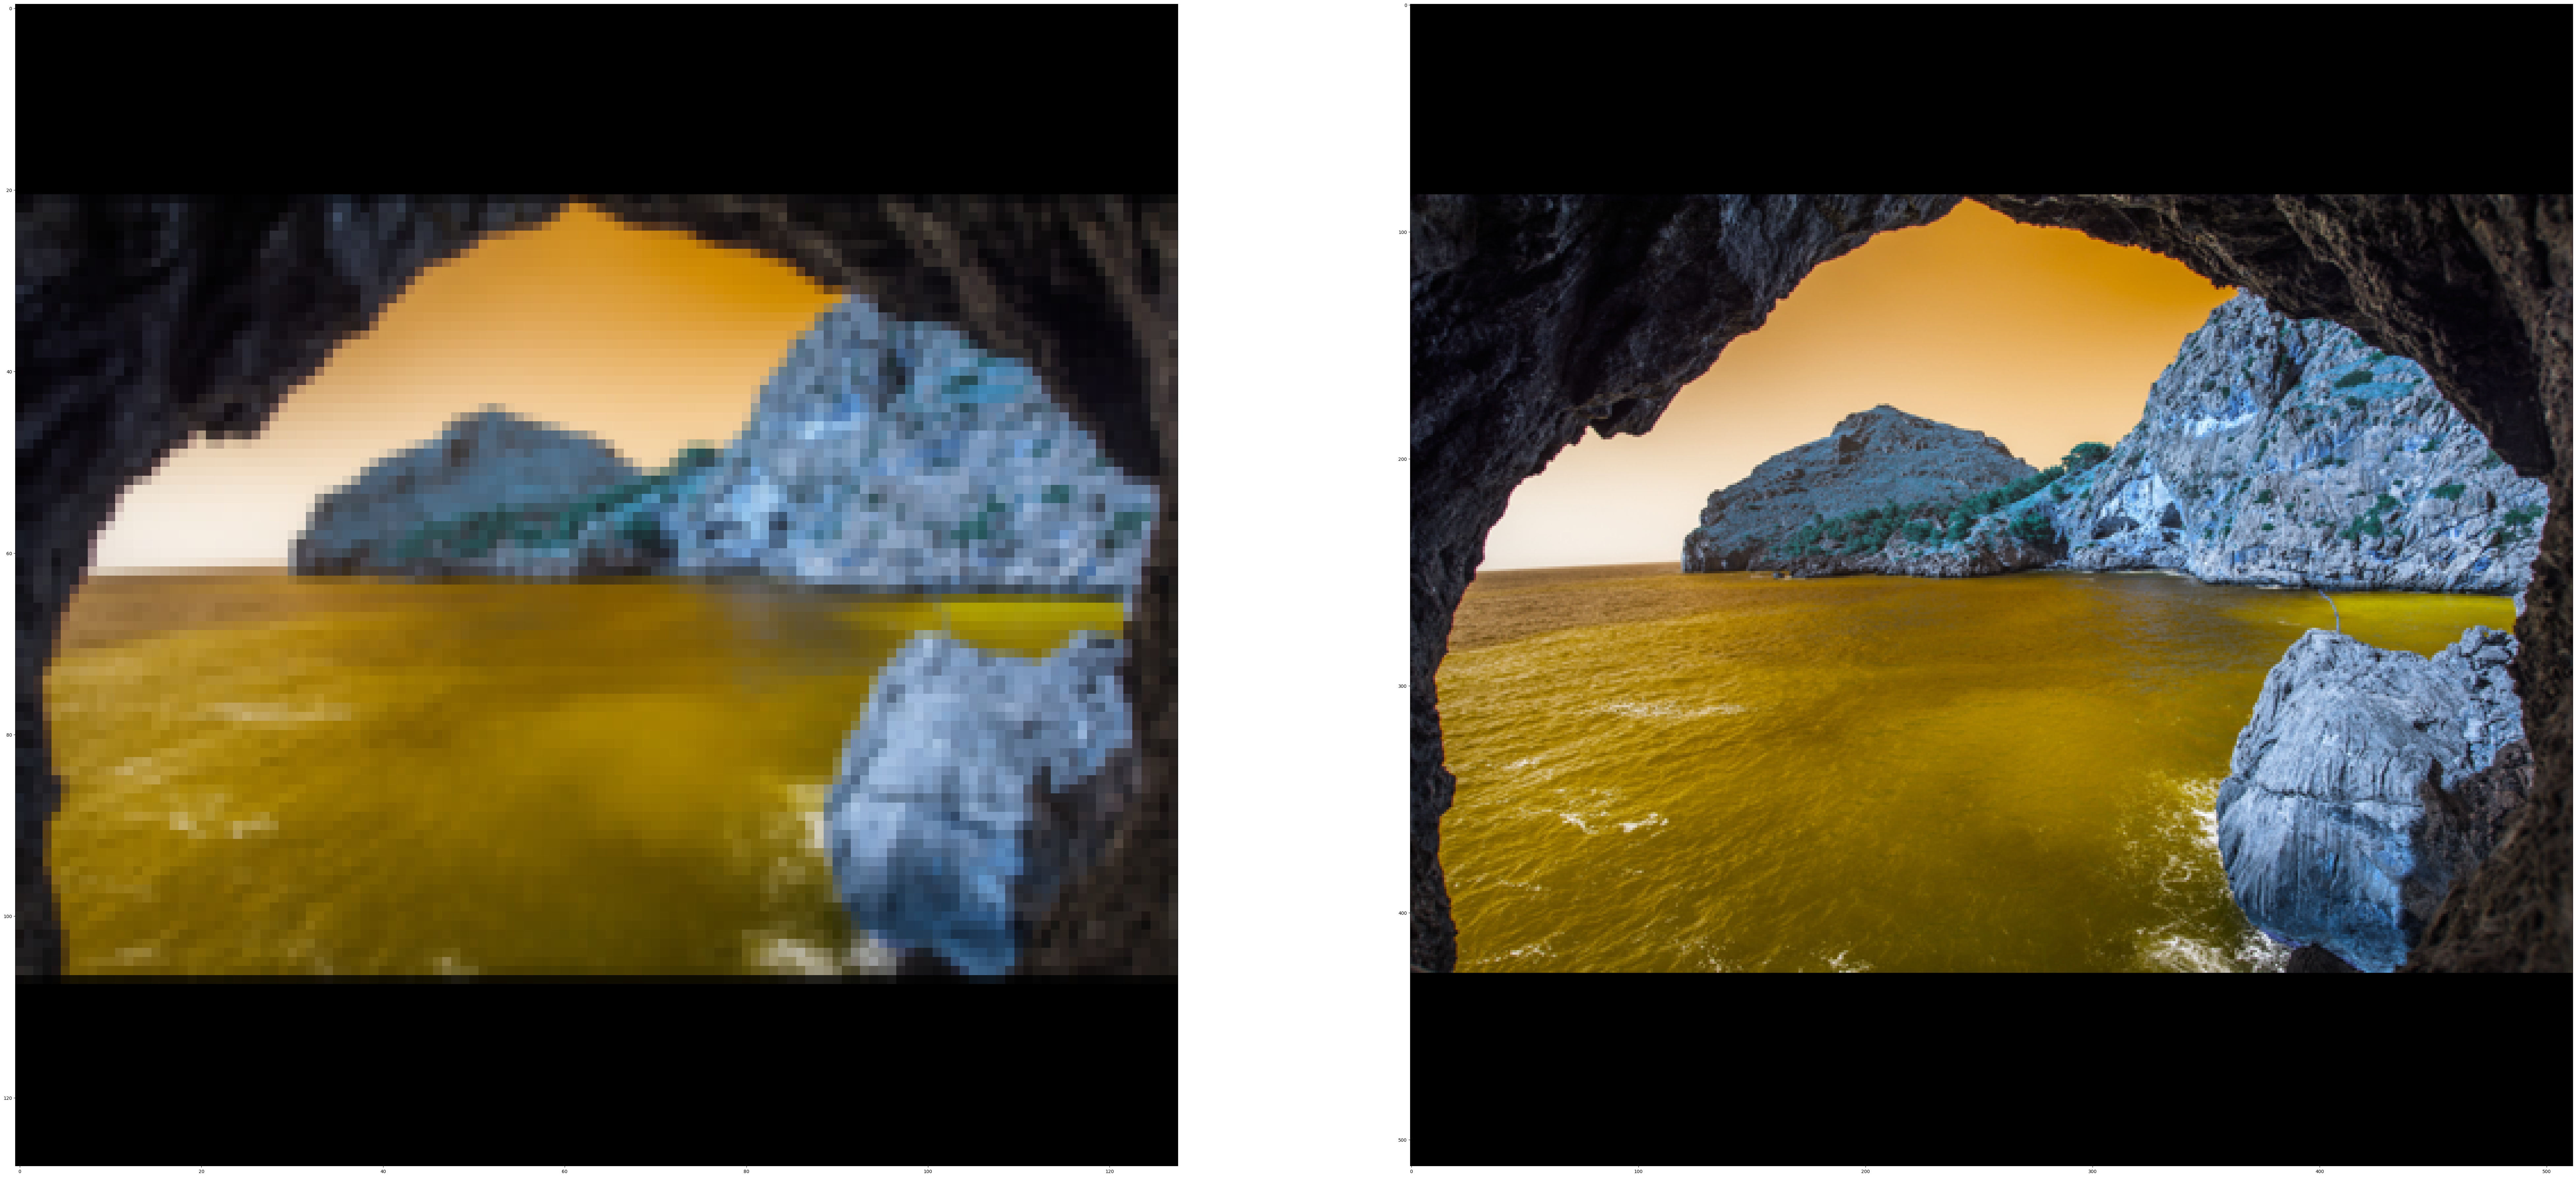

In [10]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(train_tuple[0][0])
fig.add_subplot(1,2, 2)
plt.imshow(train_tuple[0][1])

In [11]:
from torch.utils.data import Dataset
import cv2
import torch

class SRDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        low_res, high_res = self.data[idx]

        # Convert BGR to RGB
        low_res = cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB)
        high_res = cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB)

        # Convert to float and normalize to [0, 1]
        low_res = low_res.astype('float32') / 255.0
        high_res = high_res.astype('float32') / 255.0

        # Convert to PyTorch tensors in [C, H, W] format
        low_res = torch.from_numpy(low_res).permute(2, 0, 1)
        high_res = torch.from_numpy(high_res).permute(2, 0, 1)

        return low_res, high_res

# Create datasets and dataloaders
train_dataset = SRDataset(train_tuple)
test_dataset = SRDataset(test_tuple)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False)


In [12]:
train_iterator = iter(train_dataloader)
batch = next(train_iterator)
inputs, labels = batch
print(inputs.shape,labels.shape)

torch.Size([4, 3, 128, 128]) torch.Size([4, 3, 512, 512])


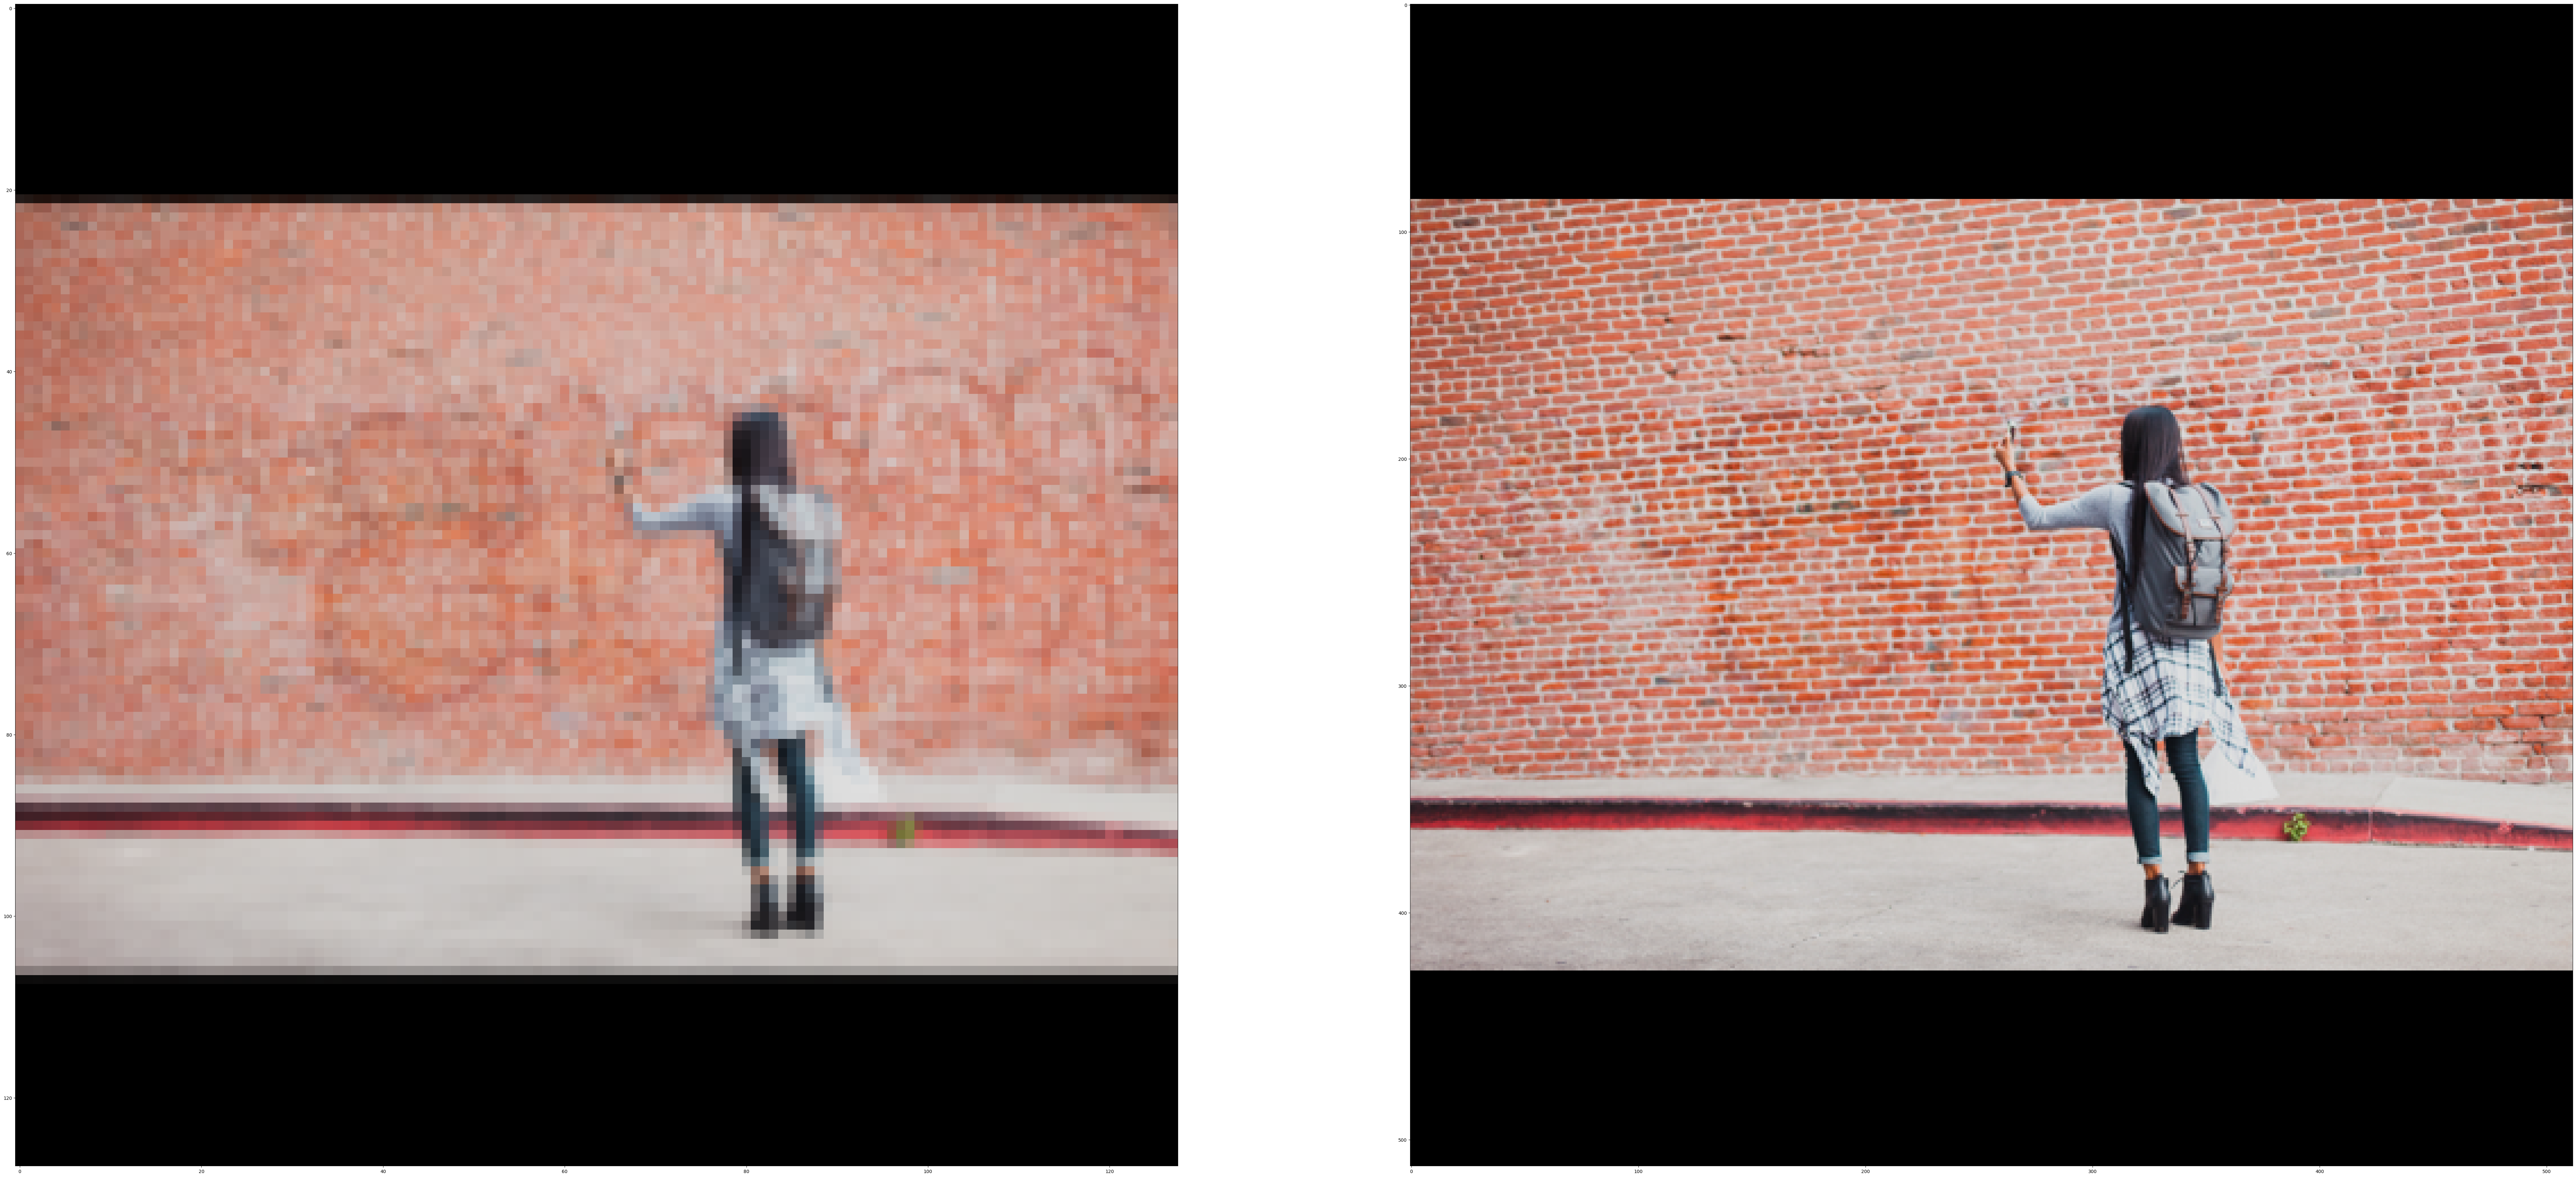

In [13]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(inputs[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))
fig.add_subplot(1,2, 2)
plt.imshow(labels[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))

In [14]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, in_channels=3, num_res_blocks=16):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU()
        )

        self.res_blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(num_res_blocks)])

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64)
        )

        # Upsampling by 2x → 256x256, then another 2x → 512x512
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
            nn.PixelShuffle(2),  # 128 → 256
            nn.PReLU(),

            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
            nn.PixelShuffle(2),  # 256 → 512
            nn.PReLU()
        )

        self.conv3 = nn.Conv2d(64, in_channels, kernel_size=9, stride=1, padding=4)

    def forward(self, x):
        initial = self.conv1(x)
        res = self.res_blocks(initial)
        res = self.conv2(res)
        out = initial + res
        out = self.upsample(out)
        out = self.conv3(out)
        return torch.clamp(out, 0.0, 1.0)  # to keep output in [0,1]

In [15]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def block(in_f, out_f, stride):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, 3, stride, 1),
                nn.BatchNorm2d(out_f),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),

            block(64, 64, 2),
            block(64, 128, 1),
            block(128, 128, 2),
            block(128, 256, 1),
            block(256, 256, 2),
            block(256, 512, 1),
            block(512, 512, 2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        return self.net(x)


In [16]:
from torchvision.models import vgg19
from torchvision.models.feature_extraction import create_feature_extractor

class VGGFeatureExtractor(nn.Module):
    def __init__(self, layer_name='features.35'):
        super().__init__()
        vgg = vgg19(pretrained=True)
        self.model = create_feature_extractor(vgg, return_nodes={layer_name: 'feat'})
        for param in self.model.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.model(x)['feat']


In [17]:
import torch
import torch.nn.functional as F

# Loss functions
adversarial_criterion = torch.nn.BCEWithLogitsLoss()
mse_criterion = torch.nn.MSELoss()
percep_loss_fn = torch.nn.MSELoss()  # can also use L1

# Optimizers
generator = Generator().to(device)
discriminator = Discriminator().to(device)
vgg = VGGFeatureExtractor().to(device)

# Enable DataParallel for multi-GPU
generator = nn.DataParallel(generator)
discriminator = nn.DataParallel(discriminator)
vgg = nn.DataParallel(vgg) 

optimizer_G = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.9, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.9, 0.999))


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:03<00:00, 184MB/s] 


In [18]:
training_loss = []
testing_loss = []

In [19]:
num_epochs = 50

def train_srgan():
    min_testing_loss = float('inf')

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        train_loss = 0.0

        for x, y in train_dataloader:
            x = x.to(device)  # [B, 3, 128, 128]
            y = y.to(device)  # [B, 3, 512, 512]

            # === Train Discriminator ===
            fake_y = generator(x)
            real_out = discriminator(y)
            fake_out = discriminator(fake_y.detach())

            real_label = torch.ones_like(real_out).to(device)
            fake_label = torch.zeros_like(fake_out).to(device)

            d_loss_real = adversarial_criterion(real_out, real_label)
            d_loss_fake = adversarial_criterion(fake_out, fake_label)
            d_loss = (d_loss_real + d_loss_fake) / 2

            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # === Train Generator ===
            fake_out = discriminator(fake_y)
            g_adv_loss = adversarial_criterion(fake_out, real_label)
            g_pixel_loss = mse_criterion(fake_y, y)
            g_percep_loss = percep_loss_fn(vgg(fake_y), vgg(y).detach())

            g_loss = g_pixel_loss + 1e-3 * g_adv_loss + 0.01 * g_percep_loss

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

            train_loss += g_loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        training_loss.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # === Evaluation ===
        if (epoch ) % 10 == 0:
            generator.eval()
            test_loss = 0.0
            with torch.no_grad():
                for x, y in test_dataloader:
                    x = x.to(device)
                    y = y.to(device)

                    fake_y = generator(x)
                    g_pixel_loss = mse_criterion(fake_y, y)
                    g_percep_loss = percep_loss_fn(vgg(fake_y), vgg(y).detach())
                    g_loss = g_pixel_loss + 0.01 * g_percep_loss

                    test_loss += g_loss.item()

            avg_test_loss = test_loss / len(test_dataloader)
            testing_loss.append(avg_test_loss)
            print(f"→ Test Loss at Epoch {epoch+1}: {avg_test_loss:.4f}")

            if avg_test_loss < min_testing_loss:
                min_testing_loss = avg_test_loss
                state = {
                    'epoch': epoch + 1,
                    'G_state_dict': generator.state_dict(),
                    'D_state_dict': discriminator.state_dict(),
                    'G_optimizer': optimizer_G.state_dict(),
                    'D_optimizer': optimizer_D.state_dict()
                }
                filepath = "model_srgan.pth"
                torch.save(state, filepath)


In [20]:
train_srgan()

Epoch 1/50, Train Loss: 0.0189
→ Test Loss at Epoch 1: 0.0095
Epoch 2/50, Train Loss: 0.0123
Epoch 3/50, Train Loss: 0.0113
Epoch 4/50, Train Loss: 0.0109
Epoch 5/50, Train Loss: 0.0103
Epoch 6/50, Train Loss: 0.0100
Epoch 7/50, Train Loss: 0.0095
Epoch 8/50, Train Loss: 0.0097
Epoch 9/50, Train Loss: 0.0093
Epoch 10/50, Train Loss: 0.0093
Epoch 11/50, Train Loss: 0.0093
→ Test Loss at Epoch 11: 0.0080
Epoch 12/50, Train Loss: 0.0094
Epoch 13/50, Train Loss: 0.0089
Epoch 14/50, Train Loss: 0.0086
Epoch 15/50, Train Loss: 0.0086
Epoch 16/50, Train Loss: 0.0088
Epoch 17/50, Train Loss: 0.0085
Epoch 18/50, Train Loss: 0.0081
Epoch 19/50, Train Loss: 0.0078
Epoch 20/50, Train Loss: 0.0077
Epoch 21/50, Train Loss: 0.0074
→ Test Loss at Epoch 21: 0.0061
Epoch 22/50, Train Loss: 0.0074
Epoch 23/50, Train Loss: 0.0072
Epoch 24/50, Train Loss: 0.0073
Epoch 25/50, Train Loss: 0.0068
Epoch 26/50, Train Loss: 0.0071
Epoch 27/50, Train Loss: 0.0068
Epoch 28/50, Train Loss: 0.0072
Epoch 29/50, Train

KeyboardInterrupt: 

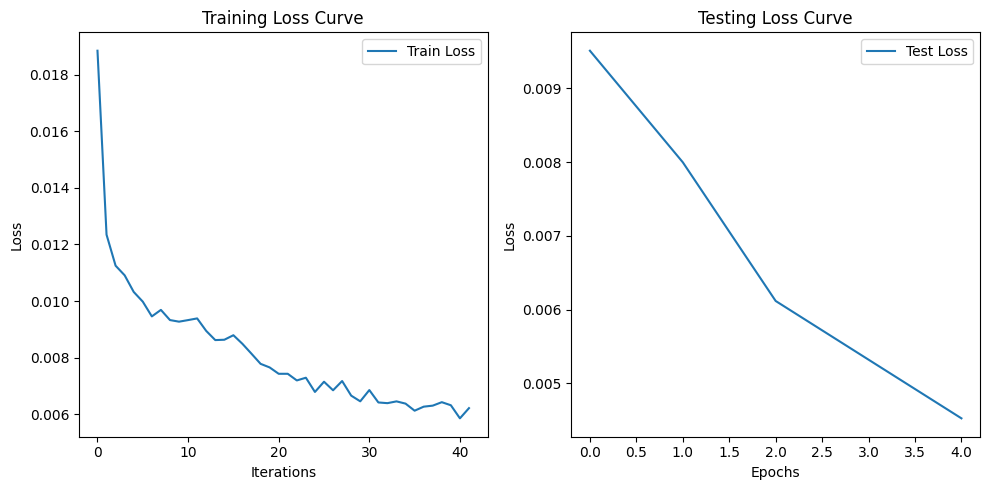

In [21]:
# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(training_loss)), training_loss, label='Train Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(testing_loss)), testing_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Testing Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
def train_result(index):
    x, y = train_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    generator.eval()
    y_fake = generator(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    generator.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


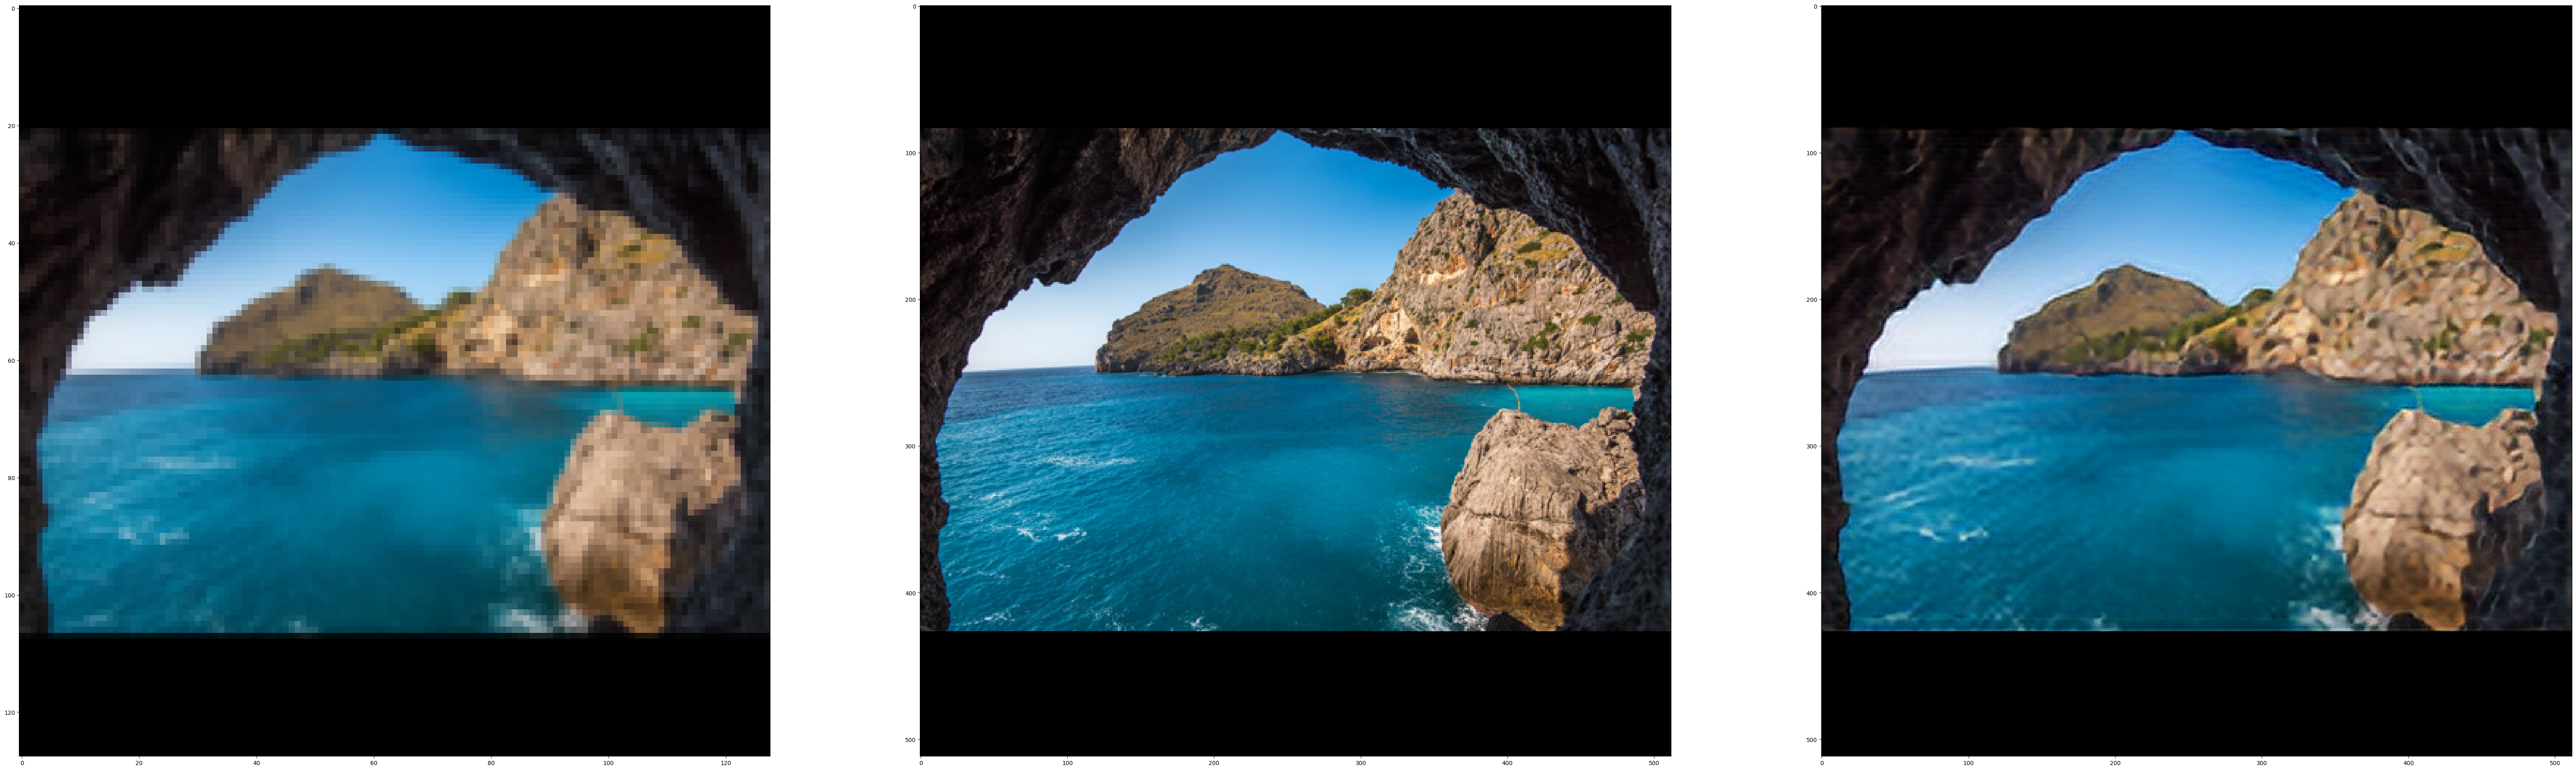

In [27]:
train_result(0)

In [28]:
def test_result(index):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    generator.eval()
    y_fake = generator(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    generator.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


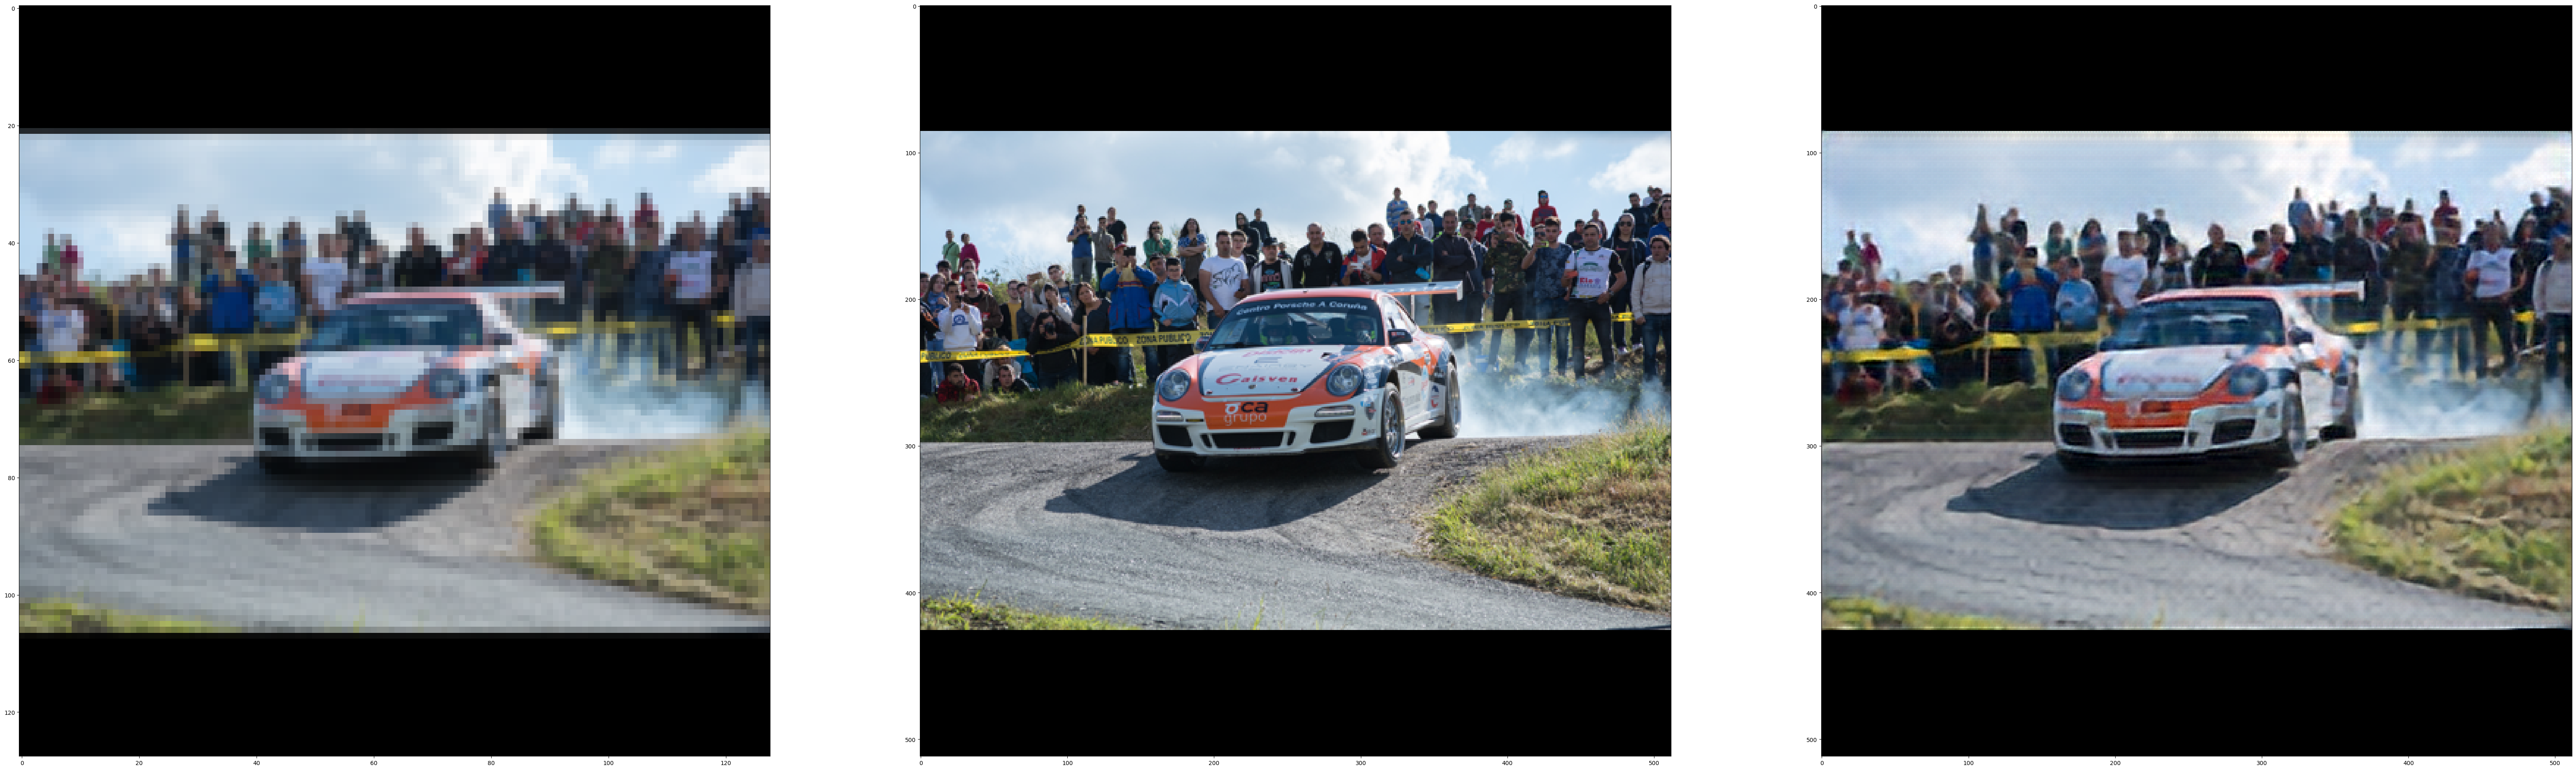

In [34]:
test_result(0)

In [39]:
import torch
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

generator.eval()
for index in range(len(test_tuple)):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Normalize
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensor [C, H, W]
    x_tensor = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
    y_tensor = torch.from_numpy(y).permute(2, 0, 1).unsqueeze(0)

    # Run model
    with torch.no_grad():
        y_fake = generator(x_tensor)

    # Convert tensors back to NumPy [H, W, C]
    y_np = y_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    y_fake_np = y_fake.squeeze().permute(1, 2, 0).cpu().numpy()

    # Clip to valid range
    y_np = np.clip(y_np, 0, 1)
    y_fake_np = np.clip(y_fake_np, 0, 1)

    # Compute metrics
    psnr_val = psnr(y_np, y_fake_np, data_range=1.0)
    ssim_val = ssim(y_np, y_fake_np, data_range=1.0, channel_axis=2)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

# Print average PSNR and SSIM
avg_psnr = sum(psnr_list) / len(psnr_list)
avg_ssim = sum(ssim_list) / len(ssim_list)

print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average SSIM: {avg_ssim:.4f}")

Average PSNR: 25.4434
Average SSIM: 0.7982


In [37]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 194.6 MB/s eta 0:00:00
